In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
Sl_Crop_df = pd.read_csv('sri_lanka_crop_dataset.csv')

In [17]:
Sl_Crop_df.shape

(15000, 10)

In [18]:
Sl_Crop_df.head()

,province,district,zone,soil_type,rainfall_mm,temperature_c,pH,season,shade,crop
0,North Central,Anuradhapura,Wet Zone,loamy,2803,30.2,6.9,Yala,yes,turmeric
1,Southern,Galle,Intermediate Zone,sandy_loam,984,26.8,4.9,Maha,yes,coconut
2,North Western,Kurunegala,Intermediate Zone,loamy,1087,27.9,6.9,Maha,yes,coconut
3,Sabaragamuwa,Kegalle,Dry Zone,clay,896,32.0,5.9,Maha,no,ginger
4,North Western,Kurunegala,Wet Zone,compost_rich,2889,23.1,5.4,Yala,yes,coconut


In [19]:
Sl_Crop_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   province       15000 non-null  object 
 1   district       15000 non-null  object 
 2   zone           15000 non-null  object 
 3   soil_type      15000 non-null  object 
 4   rainfall_mm    15000 non-null  int64  
 5   temperature_c  15000 non-null  float64
 6   pH             15000 non-null  float64
 7   season         15000 non-null  object 
 8   shade          15000 non-null  object 
 9   crop           15000 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 1.1+ MB


In [20]:
Sl_Crop_df_encoded = pd.get_dummies(Sl_Crop_df, columns=Sl_Crop_df.select_dtypes(include=['object', 'category']).columns)

In [21]:
Sl_Crop_df_encoded.head()

,rainfall_mm,temperature_c,pH,province_Central,province_Eastern,province_North Central,province_North Western,province_Northern,province_Sabaragamuwa,province_Southern,...,crop_fruits,crop_ginger,crop_maize,crop_mushroom,crop_paddy,crop_pepper,crop_rubber,crop_tea,crop_turmeric,crop_vegetables
0,2803,30.2,6.9,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,984,26.8,4.9,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2,1087,27.9,6.9,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,896,32.0,5.9,False,False,False,False,False,True,False,...,False,True,False,False,False,False,False,False,False,False
4,2889,23.1,5.4,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [22]:
Sl_Crop_df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 63 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   rainfall_mm             15000 non-null  int64  
 1   temperature_c           15000 non-null  float64
 2   pH                      15000 non-null  float64
 3   province_Central        15000 non-null  bool   
 4   province_Eastern        15000 non-null  bool   
 5   province_North Central  15000 non-null  bool   
 6   province_North Western  15000 non-null  bool   
 7   province_Northern       15000 non-null  bool   
 8   province_Sabaragamuwa   15000 non-null  bool   
 9   province_Southern       15000 non-null  bool   
 10  province_Uva            15000 non-null  bool   
 11  province_Western        15000 non-null  bool   
 12  district_Ampara         15000 non-null  bool   
 13  district_Anuradhapura   15000 non-null  bool   
 14  district_Badulla        15000 non-null

In [23]:
corr_matrix = Sl_Crop_df_encoded.corr()
print(corr_matrix.head())

                  rainfall_mm  temperature_c        pH  province_Central  \
rainfall_mm          1.000000      -0.002512  0.013426         -0.010815   
temperature_c       -0.002512       1.000000  0.013742         -0.000467   
pH                   0.013426       0.013742  1.000000         -0.001653   
province_Central    -0.010815      -0.000467 -0.001653          1.000000   
province_Eastern     0.013527      -0.005572 -0.016014         -0.124142   

                  province_Eastern  province_North Central  \
rainfall_mm               0.013527               -0.005709   
temperature_c            -0.005572                0.009327   
pH                       -0.016014               -0.000525   
province_Central         -0.124142               -0.125397   
province_Eastern          1.000000               -0.126037   

                  province_North Western  province_Northern  \
rainfall_mm                     0.003851           0.006380   
temperature_c                   0.001919    

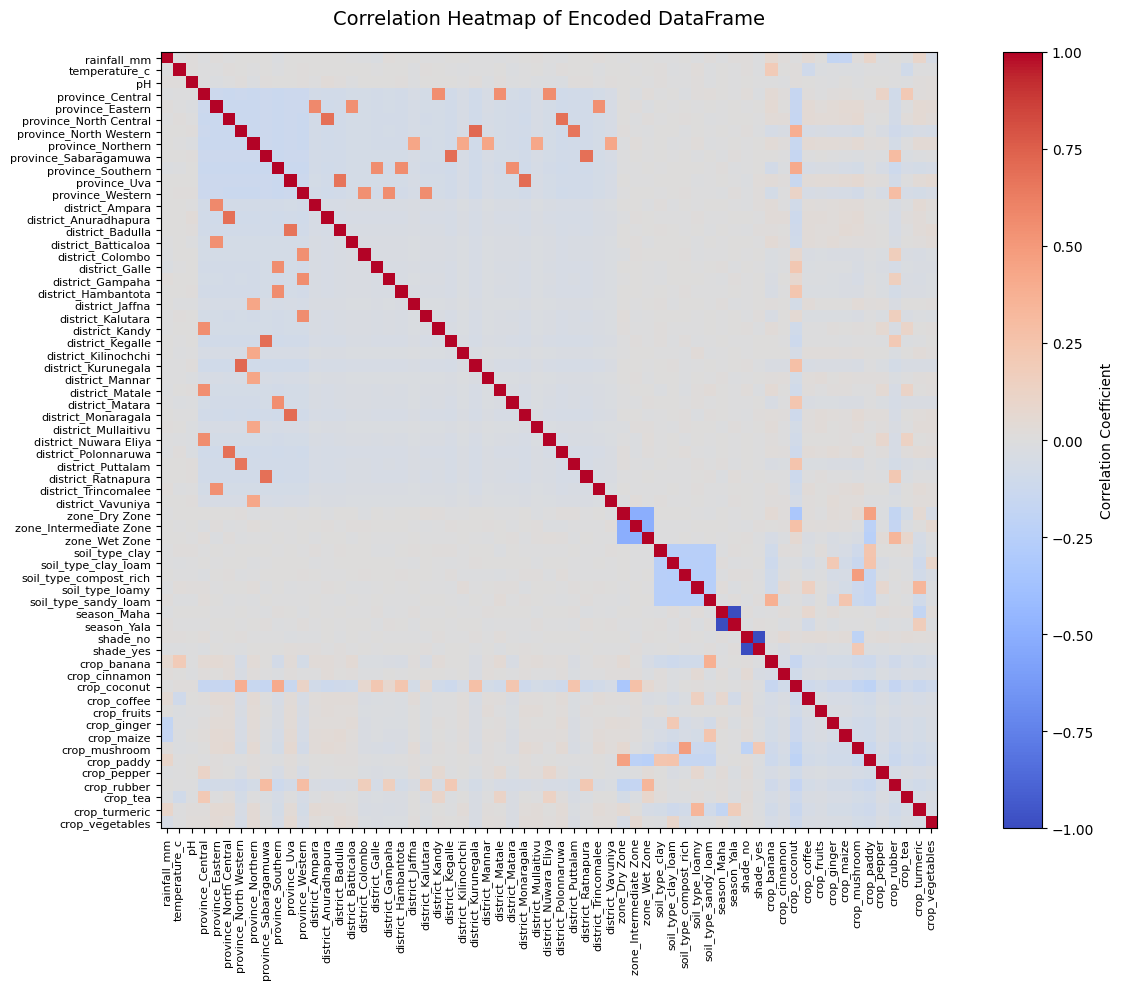

In [28]:
plt.figure(figsize=(14, 10))  # make the plot larger
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')

plt.colorbar(label='Correlation Coefficient')

plt.title("Correlation Heatmap of Encoded DataFrame", fontsize=14, pad=20)

# Smaller axis labels for readability
plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90,
    fontsize=8
)
plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    fontsize=8
)

# Add gridlines for clarity
plt.grid(False)
plt.tight_layout()
plt.show()

### Correlation with Rain Fall

In [30]:
# Sort correlations by absolute value
Correlation_plot = Sl_Crop_df_encoded.corr()['rainfall_mm'].drop('rainfall_mm').sort_values(key=abs, ascending=False)
print(Correlation_plot)

crop_ginger              -0.175648
crop_maize               -0.168627
crop_paddy                0.100891
crop_turmeric             0.097632
crop_banana               0.065306
                            ...   
province_Western          0.000996
zone_Wet Zone             0.000918
district_Anuradhapura     0.000650
district_Badulla          0.000518
zone_Intermediate Zone    0.000206
Name: rainfall_mm, Length: 62, dtype: float64


In [36]:
crop_corr = Correlation_plot[Correlation_plot.index.str.startswith('crop_')]
crop_corr_sorted = crop_corr.sort_values()

In [39]:
bottom6_corr_Crop_rainfall = crop_corr_sorted.head(6)
print(bottom6_corr_Crop_rainfall)

crop_ginger       -0.175648
crop_maize        -0.168627
crop_vegetables   -0.048295
crop_tea          -0.014304
crop_pepper       -0.010289
crop_coconut      -0.007337
Name: rainfall_mm, dtype: float64


In [40]:
top6_corr_Crop_rainfall = crop_corr_sorted.tail(6)
print(top6_corr_Crop_rainfall)

crop_mushroom    0.011490
crop_cinnamon    0.016145
crop_coffee      0.046111
crop_banana      0.065306
crop_turmeric    0.097632
crop_paddy       0.100891
Name: rainfall_mm, dtype: float64


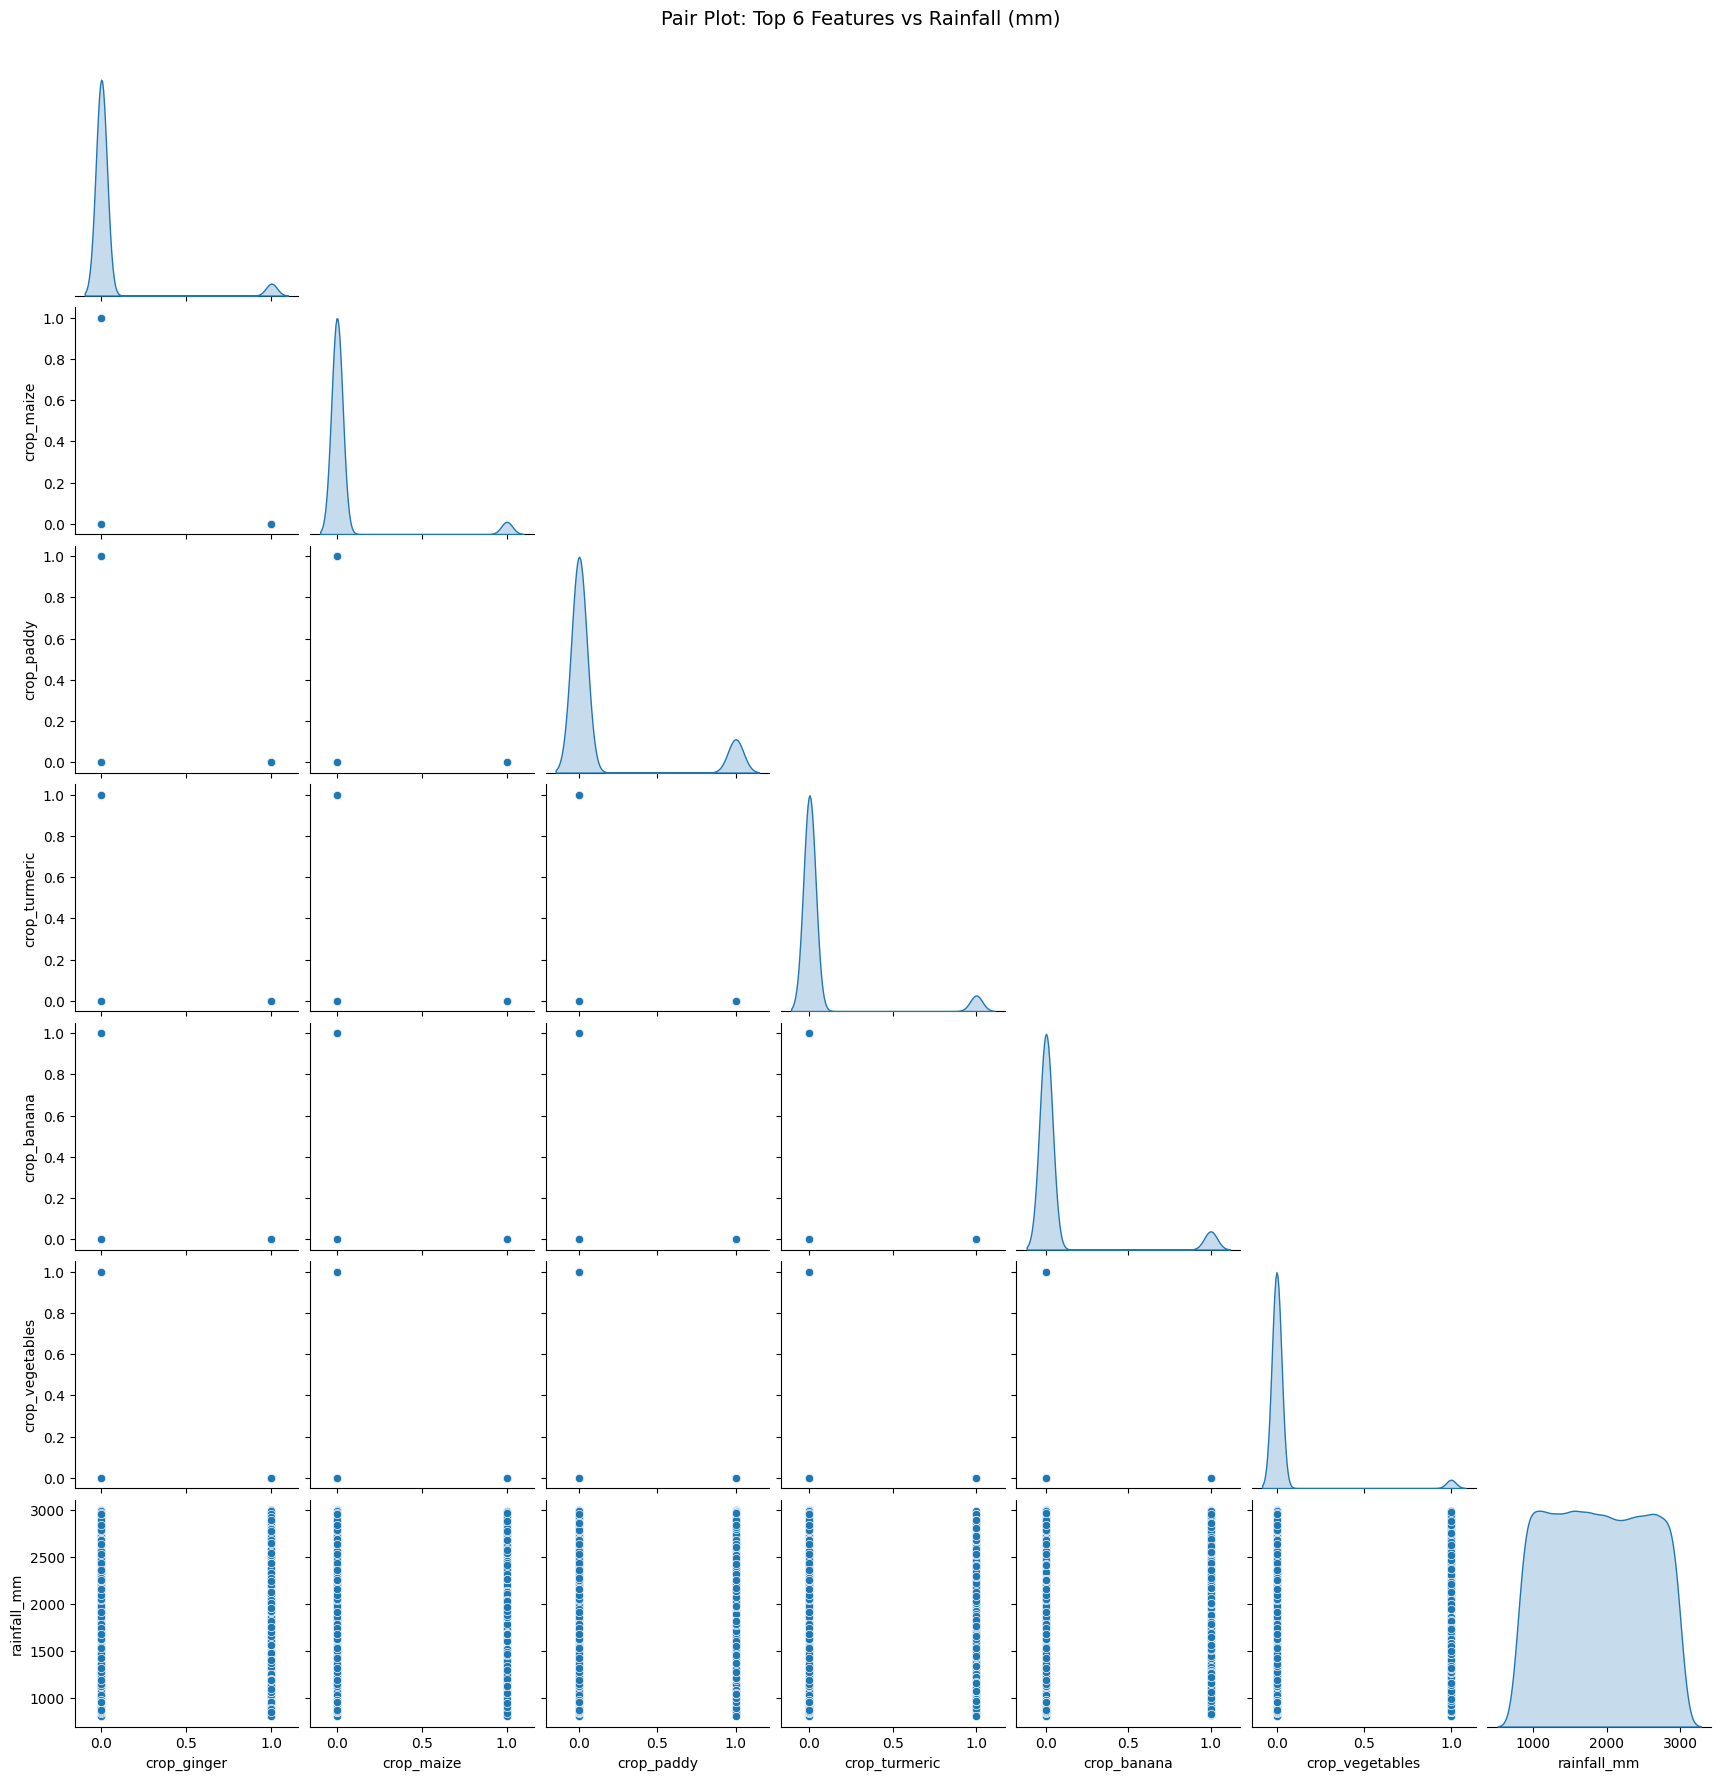

In [32]:
# Select top N correlated features
top_n = 6
top_features = Correlation_plot.head(top_n).index.tolist() + ['rainfall_mm']

# Create pairplot for top features
sns.pairplot(Sl_Crop_df_encoded[top_features], diag_kind='kde', corner=True)
plt.suptitle(f'Pair Plot: Top {top_n} Features vs Rainfall (mm)', fontsize=14, y=1.02)
plt.show()

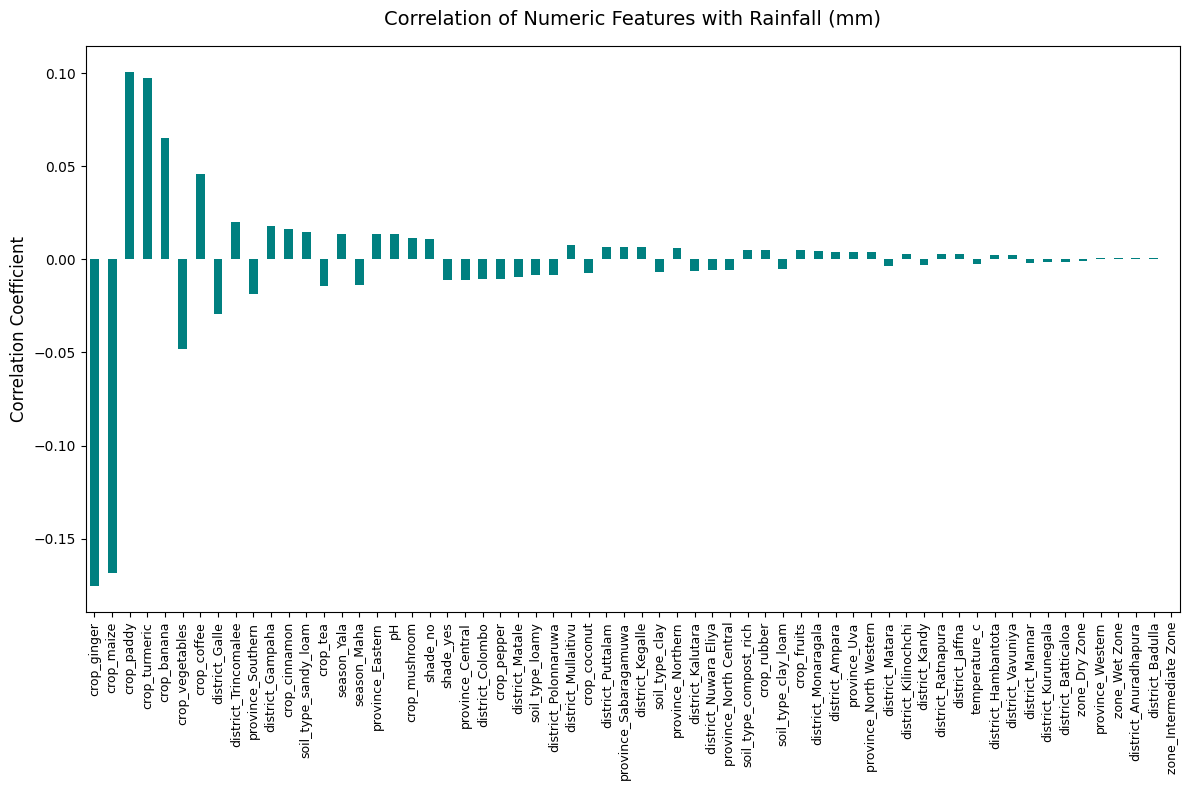

In [31]:
plt.figure(figsize=(12, 8))  # bigger figure for readability
Correlation_plot.plot(kind='bar', color='teal')

plt.title('Correlation of Numeric Features with Rainfall (mm)', fontsize=14, pad=15)
plt.ylabel('Correlation Coefficient', fontsize=12)
plt.xticks(rotation=90, fontsize=9)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()